## K-means Clustering

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from mpl_toolkits.mplot3d import Axes3D

### K-Means From Scratch

In [7]:
def find_closest_centroids(X, centroids):
    K = centroids.shape[0]
    idx = np.zeros(X.shape[0], dtype=int)

    for i in range(len(idx)):
        distances = []
        for k in range(K):
            distances.append(np.sum((X[i] - centroids[k]) ** 2))
        idx[i] = distances.index(np.min(distances))

    return idx

In [5]:
X = np.load("data/ex7_X.npy")
print("First 5 element of X\n", X[:5])
print("\nShape of X: ", X.shape)

First 5 element of X
 [[1.84207953 4.6075716 ]
 [5.65858312 4.79996405]
 [6.35257892 3.2908545 ]
 [2.90401653 4.61220411]
 [3.23197916 4.93989405]]

Shape of X:  (300, 2)


In [8]:
initial_centroids = np.array([[3,3], [6,2], [8,5]])

idx = find_closest_centroids(X, initial_centroids)

print("First 3 elements in idx are: ", idx[:3])

First 3 elements in idx are:  [0 2 1]


In [9]:
def compute_centroids(X, idx, K):
    m, n = X.shape
    centroids = np.zeros((K, n))

    for k in range(K):
        datas = X[idx == k]
        centroids[k] = np.mean(datas, axis=0)

    return centroids

In [10]:
K = 3
centroids = compute_centroids(X, idx, K)
print("The centroids are: ", centroids)

The centroids are:  [[2.42830111 3.15792418]
 [5.81350331 2.63365645]
 [7.11938687 3.6166844 ]]


In [14]:
def kMeans_init_centroids(X, K):
    randidx = np.random.permutation(X.shape[0])
    centroids = X[randidx[:K]]
    
    return centroids

In [32]:
def plot_progress_kMeans(X, centroids, previous_centroids, idx, K, i):
    cmap = ListedColormap(["red", "green", "blue"])
    c = cmap(idx)
    plt.scatter(X[:, 0], X[:, 1], facecolors='none', edgecolors=c, linewidth=0.1, alpha=0.7)
    plt.scatter(centroids[:, 0], centroids[:, 1], marker='x', c='k', linewidths=3)
    
    for j in range(centroids.shape[0]):
        plt.plot([centroids[j, :][0], previous_centroids[j, :][0]],
                 [centroids[j, :][1], previous_centroids[j, :][1]], "-k", linewidth=1)
    
    plt.title("Iteration number %d" %i)

In [30]:
def run_kMeans(X, initial_centroids, max_iters=10, plot_progress=False):
    m, n = X.shape
    K = initial_centroids.shape[0]
    centroids = initial_centroids
    previous_centroids = centroids
    idx = np.zeros(m)
    plt.figure(figsize=(8,6))

    for i in range(max_iters):
        print("K-Means iteration %d/%d" % (i, max_iters))
        idx = find_closest_centroids(X, centroids)

        if plot_progress:
            plot_progress_kMeans(X, centroids, previous_centroids, idx, K, i)
            previous_centroids = centroids

        centroids = compute_centroids(X, idx, K)
    plt.show()

    return centroids, idx

K-Means iteration 0/10
K-Means iteration 1/10
K-Means iteration 2/10
K-Means iteration 3/10
K-Means iteration 4/10
K-Means iteration 5/10
K-Means iteration 6/10
K-Means iteration 7/10
K-Means iteration 8/10
K-Means iteration 9/10


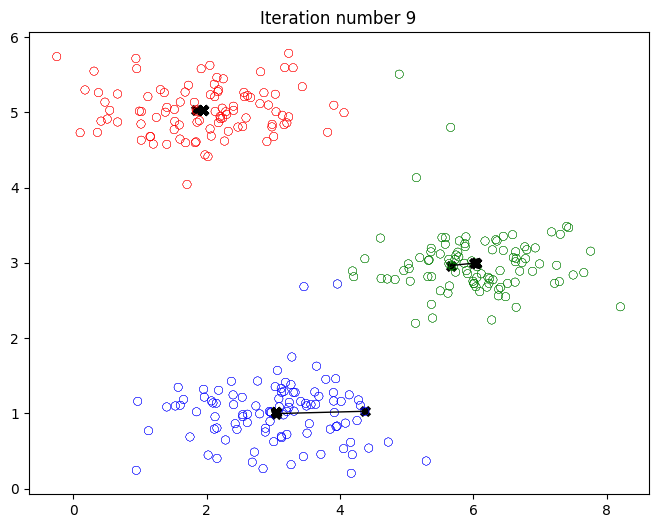

In [34]:
K = 3 
max_iters = 10

initial_centroids = kMeans_init_centroids(X, K)

centroids, idx = run_kMeans(X, initial_centroids, max_iters, plot_progress=True)

### Image Compression with K-Means

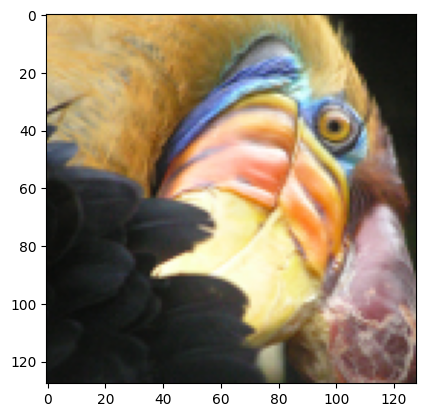

In [35]:
original_img = plt.imread('bird_small.png')
plt.imshow(original_img)

In [36]:
print("Shape of original image: ", original_img.shape)

Shape of original image:  (128, 128, 3)


In [39]:
X_img = np.reshape(original_img, (original_img.shape[0] * original_img.shape[1], 3))

In [40]:
K = 16
max_iters = 10
initial_centroids = kMeans_init_centroids(X_img, K)
centroids, idx = run_kMeans(X_img, initial_centroids, max_iters)

K-Means iteration 0/10
K-Means iteration 1/10
K-Means iteration 2/10
K-Means iteration 3/10
K-Means iteration 4/10
K-Means iteration 5/10
K-Means iteration 6/10
K-Means iteration 7/10
K-Means iteration 8/10
K-Means iteration 9/10


<Figure size 800x600 with 0 Axes>

In [41]:
print("Shape of idx: ", idx.shape)
print("First 5 elements of idx: ", idx[:5])

Shape of idx:  (16384,)
First 5 elements of idx:  [11 11 11 11 11]


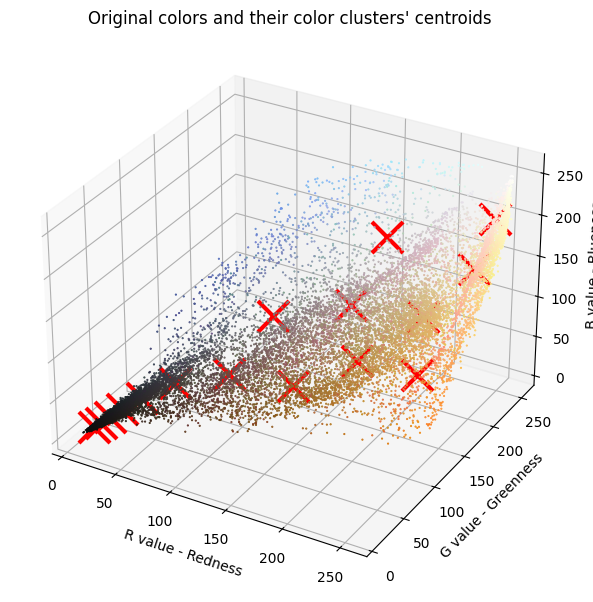

In [45]:
fig = plt.figure(figsize=(16, 16))
ax = fig.add_subplot(221, projection='3d')
ax.scatter(*X_img.T*255, zdir='z', depthshade=False, s=.3, c=X_img)
ax.scatter(*centroids.T*255, zdir='z', depthshade=False, s=500, c='red', marker='x', lw=3)
ax.set_xlabel('R value - Redness')
ax.set_ylabel('G value - Greenness')
ax.set_zlabel('B value - Blueness')
ax.set_title("Original colors and their color clusters' centroids")
plt.show()

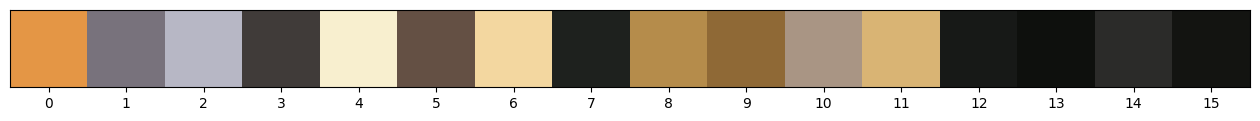

In [46]:
palette = np.expand_dims(centroids, axis=0)
num = np.arange(0,len(centroids))
plt.figure(figsize=(16, 16))
plt.xticks(num)
plt.yticks([])
plt.imshow(palette)

In [47]:
idx = find_closest_centroids(X_img, centroids)
X_recovered = centroids[idx, :]
X_recovered = np.reshape(X_recovered, original_img.shape)

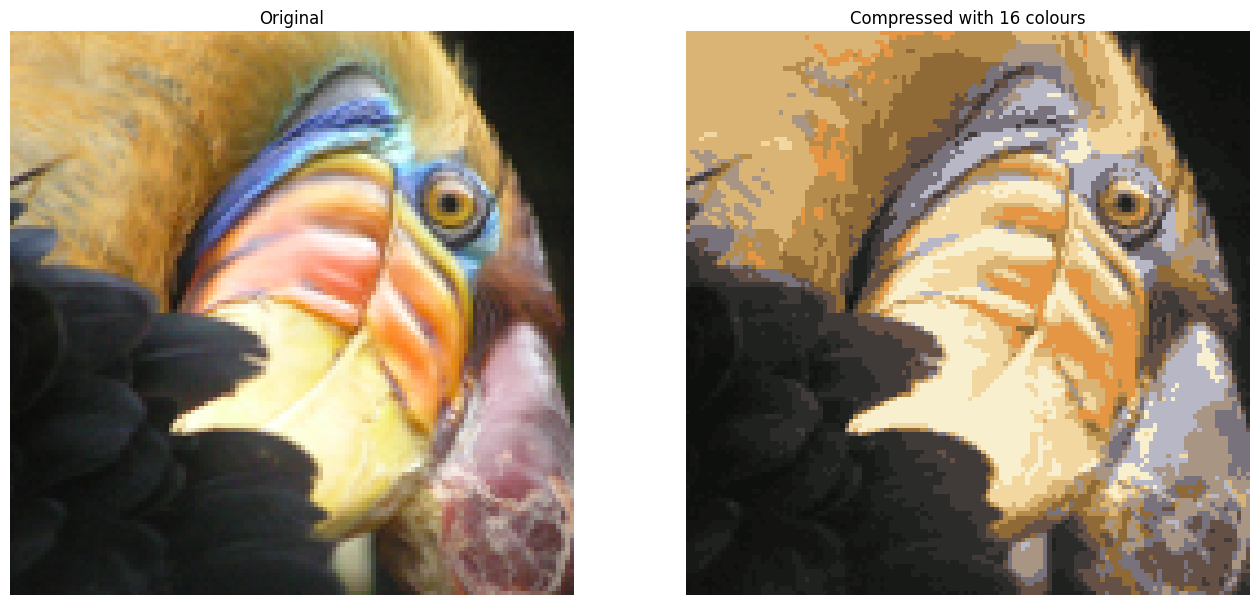

In [48]:
fig, ax = plt.subplots(1,2, figsize=(16,16))
plt.axis('off')

ax[0].imshow(original_img)
ax[0].set_title('Original')
ax[0].set_axis_off()

ax[1].imshow(X_recovered)
ax[1].set_title('Compressed with %d colours'%K)
ax[1].set_axis_off()